## Vignette to apply FRAPPPE for flux ratio analysis on E. coli reference dataset

This vignette produces all figures from Figure 1b, c as well as Supplementary Figures 1 and 2.
Before running the vignette, download the Data folder

In [ ]:
from freeflux import Model, Metabolite, Reaction
from mfa import replace_uptake_reaction, make_bounds, sample_fluxes, shuffle_labeling_pattern, get_mdv_dict, carb_exch, get_mdv_results_from_simulations, calc_net_fluxes, build_flux_ratios, calc_ratios_from_sims, plot_flux_ratios, sample_ratio_specific_fluxsets, get_flux_ratio, get_flux_ratio_wide, eval_RF_sim_pred, get_reconex_fluxes
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from scipy.io import loadmat
import numpy as np
from matplotlib.pyplot import figure
import os


# load read sumoflux data

def expand_metabolite_name(name):
    """
    Expand a metabolite name like 'OAA14' into
    ['OAA14_m0', 'OAA14_m1', ..., 'OAA14_mN']
    where N = (d2 - d1) + 1
    """
    match = re.match(r"(.+?)(\d)(\d)$", name)
    if not match:
        raise ValueError(f"Unexpected metabolite format: {name}")

    base, d1, d2 = match.groups()
    d1, d2 = int(d1), int(d2)

    n = (d2 - d1) + 2
    return [f"{name}_m{i}" for i in range(n)]


def matmdvs_to_pd(path_to_mat):
    
    mat = loadmat(path_to_mat)
    
    colnames = [
        x[0] for x in mat["experimentalStrains"].ravel()
    ]

    rownames = [
        x[0] for x in mat["metabolites_measured"].ravel()
    ]
    
    expanded_rownames = []
    for r in rownames:
        expanded_rownames.extend(expand_metabolite_name(r))

    # rename OGA (oxoglutaric acid) to AKG (alpha-ketoglutarate) --> more canonical
    
    expanded_rownames = [re.sub("OGA", "AKG", x) for x in expanded_rownames]
    expanded_rownames = [re.sub("PYR", "Pyr", x) for x in expanded_rownames]

    data = pd.DataFrame(
        mat["experimentalData"], index = expanded_rownames, columns = colnames
    )    
    
    return(data)

def add_noise(data, noise_scale=0.01, seed=42):
    rng = np.random.default_rng(seed)
    new_data = (data + rng.uniform(-noise_scale, noise_scale, size=data.shape)).abs()
    return new_data / new_data.sum(axis=0) 


KeyboardInterrupt: 

In [ ]:
# create directories
# download the data repo "Data" before running the vignette
os.makedir("Output/Ecoli_aerobic/ratio_specific_simulations/", exist_ok = True)
os.makedir("Output/Ecoli_aerobic/predictors_w_noise/", exist_ok = True)



In [ ]:
target_emus_100_113C = {
    "OAA": "12", 
    "PEP": "12",
    "Pyr": ["123", "23"], 
    "BPG": ["123", "23", "12"]
}

target_emus_20_U13C = {
    "OAA": ["1234", "234"], 
    "AKG": "2345", 
    "PEP": ["123", "23", "12"],
    "Pyr": ["123","23"], 
    "BPG": "123"
}


# load labeling data from Ecoli experiments


measured_20_U13C = matmdvs_to_pd("../Data/Ecoli_aerobic/SUMOFLUXexperimentalData_ECOLI20U13C.mat")
measured_100_113C = matmdvs_to_pd("../Data/Ecoli_aerobic/SUMOFLUXexperimentalData_ECOLI113C.mat")

# Arrange and re-structure input data

new_index = [r
     .replace("OAA12_m", "OAA_12_")
     .replace("PEP12_m", "PEP_12_")
     .replace("Pyr13_m", "Pyr_123_")
     .replace("Pyr23_m", "Pyr_23_")
     .replace("BPG13_m", "BPG_123_")
     .replace("BPG12_m", "BPG_12_")
     .replace("BPG23_m", "BPG_23_") 
    for r in measured_100_113C.index
]
measured_100_113C.index = new_index
measured_100_113C_sorted = measured_100_113C.sort_index().copy()


new_index = [r
             .replace("OAA14_m", "OAA_1234_")
             .replace("OAA24_m", "OAA_234_")
             .replace("AKG25_m", "AKG_2345_")
             .replace("PEP13_m", "PEP_123_")
             .replace("PEP23_m", "PEP_23_")
             .replace("PEP12_m", "PEP_12_")
             .replace("Pyr13_m", "Pyr_123_")
             .replace("Pyr23_m", "Pyr_23_")
             .replace("BPG13_m", "BPG_123_") for r in measured_20_U13C.index]

measured_20_U13C.index = new_index
measured_20_U13C_sorted = measured_20_U13C.sort_index().copy()


flux_ratios_dict = {
    "glycolysis_PPP": (["pgi"], ["pgi", "zwf"]),
    "pyruvate_from_ED": (["edp2"], ["edp2", "pyk", "mae"]),
    "gluconeogenesis": (["pck"], ["pck", "eno"]),
    "pyruvate_from_malic_enzyme": (["mae"], ["mae", "pyk", "edp2"]),
    "anaplerosis": (["pyc"], ["pyc", "sdh", "gs1"])
}


Glc_20_U13C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111'], 
    percentage = [0.2], 
    purity = [0.994]    
)


Glc_100_113C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['100000'], 
    percentage = [1], 
    purity = [0.994]    
)




## Double check flux distributions through comparison with old sumoflux fluxes

In [ ]:
def get_sumoflux_fluxes(file_prefix):
    df_sumoflux_f = pd.read_csv(f"{file_prefix}_f.csv")
    df_sumoflux_b = pd.read_csv(f"{file_prefix}_b.csv")
    return pd.concat(
        [
            df_sumoflux_f.query("r_irreversible == 1"),
            df_sumoflux_b.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_b"),
            df_sumoflux_f.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_f")
        ],
        ignore_index=True
    )


def melt_flux_df(data, **kwargs):
    return (
        data
        .reset_index(names="reaction_id")
        .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux")
        .assign(**kwargs)
    )

df_100_1_13c_sumoflux_fluxes = (
    get_sumoflux_fluxes("../Data/Ecoli_aerobic/simulated_ECOLI113C/fluxTable")
    .drop(columns=["r_equation", "r_irreversible"])
    .rename(columns={"Row": "reaction_id"})
    .set_index("reaction_id")
)



In [ ]:

ecoli_model_file = "../Data/Models/Ecoli/reactions_model_inca_ecoli_corrected.tsv"
ecoli_model = Model("syn_wo_ends")
ecoli_model.read_from_file(ecoli_model_file)

stoic_mat = ecoli_model.get_total_stoichiometric_matrix() 

lb, ub = make_bounds(stoic_mat, 0, 100, specific={"glc_up": [10, 10]})


In [ ]:
ecoli_fluxes = sample_fluxes(stoic_mat, 100000, lb, ub, thinning = 1000)

ecoli_fluxes.to_csv("../Output/Ecoli_aerobic/Ecoli_fluxes_unconstrained.csv")

In [ ]:
ecoli_fluxes = pd.read_csv("../Output/Ecoli_aerobic/Ecoli_fluxes_unconstrained.csv", index_col = "Unnamed: 0")

In [ ]:
ecoli_fluxes_reconex = get_reconex_fluxes(ecoli_fluxes)

In [ ]:
ecoli_fluxes_reconex.to_csv("../Output/Ecoli_aerobic/Ecoli_fluxes_reconstrained.csv")

In [ ]:
ecoli_fluxes_reconex = pd.read_csv("../Output/Ecoli_aerobic/Ecoli_fluxes_reconstrained.csv", index_col = "Unnamed: 0")

In [ ]:
pd.set_option('display.max_rows', None)

/tmp/ipykernel_2659209/798535408.py:2: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.80)


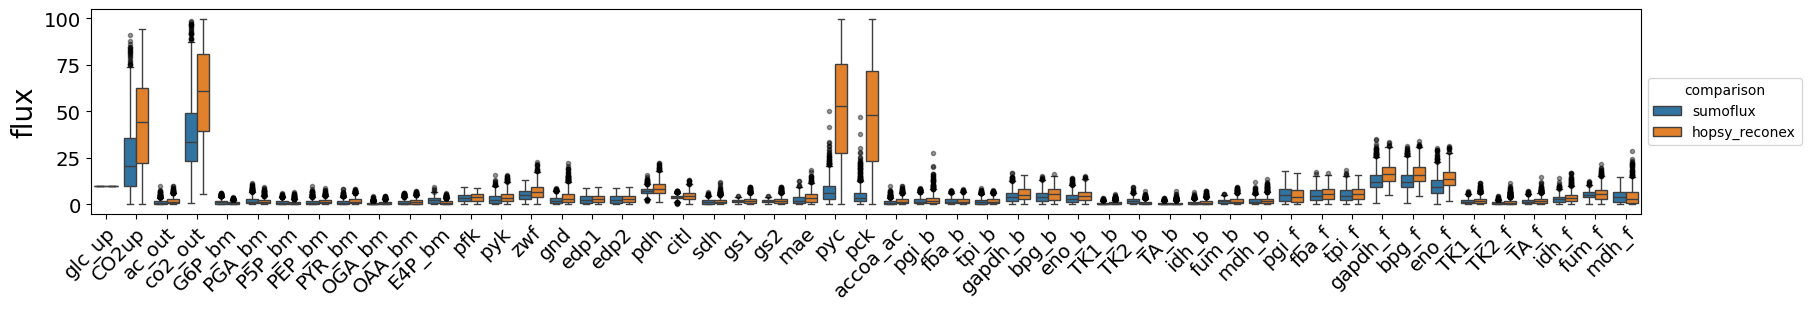

In [ ]:
fig, ax = plt.subplots(figsize=(18, 3), constrained_layout=True)
fig.subplots_adjust(right=0.80)
b = sns.boxplot(
    pd.concat([
        df_100_1_13c_sumoflux_fluxes
            .sample(1000, axis=1, random_state=42)
            .pipe(melt_flux_df, comparison="sumoflux"), 
        ecoli_fluxes_reconex
            .sample(1000, axis=1, random_state=42)
            .pipe(melt_flux_df, comparison = "hopsy_reconex")
    ]),
    x="reaction_id", 
    y="flux",
    flierprops = dict(
        marker = "o", 
        markersize = 3, 
        markerfacecolor = 'black', 
        markeredgecolor = "black",
        alpha = 0.4
        
    ),
    hue="comparison",
    dodge=True
)
b.tick_params(labelsize = 14.2)
b.set_xlabel("", fontsize = 20)
b.set_ylabel("flux", fontsize = 20)
sns.move_legend(ax, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.tick_params(axis="x", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
plt.savefig("../Output/Ecoli_aerobic/flux_distribution_comparison.pdf")

In [ ]:
sample_ratio_specific_fluxsets(
    path_to_fluxes="../Output/Ecoli_aerobic/Ecoli_fluxes_reconstrained.csv", 
    path_to_output_dir="../Output/Ecoli_aerobic/ratio_specific_simulations/", 
    flux_ratios_dict=flux_ratios_dict, 
    samples_per_bin=1000
)

## Simulate mdvs for subsampled fluxes in 20% U13C Glucose condition

In [ ]:
for r in flux_ratios_dict.keys():
    print(r)
    if not Path("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C.csv").exists():
        print("File does not exist, simulating mdvs")
        # read in subsampled fluxes
        fluxes_subsampled = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
        mdvs_subsampled = get_mdv_results_from_simulations(ecoli_model, fluxes_subsampled, target_emus_20_U13C, Glc_20_U13C, parallel=8, as_df=True)
        mdvs_subsampled.columns = fluxes_subsampled.columns
        mdvs_subsampled.sort_index().to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C.csv")
    else: 
        print("simulations already conducted, going to next ratio")
        

glycolysis_PPP
File does not exist, simulating mdvs
pyruvate_from_ED
File does not exist, simulating mdvs
gluconeogenesis
File does not exist, simulating mdvs
pyruvate_from_malic_enzyme
File does not exist, simulating mdvs
anaplerosis
File does not exist, simulating mdvs


## Simulate mdvs for subsampled fluxes in 100% 1-13C Glucose condition

In [ ]:
for r in flux_ratios_dict.keys():
    print(r)
    if not Path("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C.csv").exists():
        print("File does not exist, simulating mdvs")
        
        # read in subsampled fluxes
        fluxes_subsampled = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
        mdvs_subsampled = get_mdv_results_from_simulations(ecoli_model, fluxes_subsampled, target_emus_100_113C, Glc_100_113C, parallel=8, as_df=True)
        mdvs_subsampled.columns = fluxes_subsampled.columns
        mdvs_subsampled.sort_index().to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C.csv")
    
    else: 
        print("simulations already conducted, going to next ratio")

glycolysis_PPP
File does not exist, simulating mdvs
pyruvate_from_ED
File does not exist, simulating mdvs
gluconeogenesis
File does not exist, simulating mdvs
pyruvate_from_malic_enzyme
File does not exist, simulating mdvs
anaplerosis
File does not exist, simulating mdvs


## Add noise to simulated MDVs in 20% U-13C Glucose condition

In [ ]:
# per file, read in subset, add noise, filter low-abundant feats and write it again

flux_ratios_dict_20_U13C = {k: flux_ratios_dict[k] for k in ["pyruvate_from_malic_enzyme", "anaplerosis"]}

for r in flux_ratios_dict_20_U13C.keys():
    
    mdvs = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C.csv", index_col = "Unnamed: 0")
    
    mdvs_wnoise = (
        mdvs
        .reset_index(names="isotopo")
        .assign(mb=lambda x: x.isotopo.str.extract("(.*_.*)_.*"))
        .set_index("isotopo")
        .groupby("mb")
        .transform(add_noise)
    )
    
    mdvs_sel = (
        mdvs_wnoise[(mdvs_wnoise > 0.05).any(axis=1)]
        .reset_index(names = "Unnamed: 0")
        .set_index("Unnamed: 0")
    )
    
    
    print(mdvs_sel)
    
    mdvs_sel.to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C_wnoise_filtered.csv")



               61582     51007     62242     26227      5733      3145  \
Unnamed: 0                                                               
AKG_2345_0  0.554361  0.488843  0.527839  0.542684  0.496159  0.569153   
AKG_2345_1  0.143899  0.261699  0.193550  0.167052  0.248916  0.115893   
AKG_2345_2  0.249837  0.198536  0.224415  0.235583  0.203385  0.264763   
AKG_2345_3  0.035171  0.046442  0.043149  0.040930  0.045829  0.030172   
BPG_123_0   0.762836  0.730127  0.752601  0.766491  0.731408  0.761377   
BPG_123_1   0.029121  0.065850  0.039309  0.025544  0.068686  0.030631   
BPG_123_2   0.016042  0.042697  0.026334  0.012237  0.032898  0.017409   
BPG_123_3   0.192001  0.161326  0.181756  0.195728  0.167009  0.190583   
OAA_1234_0  0.586894  0.571389  0.574373  0.559294  0.587882  0.676976   
OAA_1234_1  0.201223  0.238664  0.212054  0.226656  0.222334  0.116903   
OAA_1234_2  0.072295  0.104966  0.105975  0.094941  0.090450  0.053273   
OAA_1234_3  0.123236  0.083386  0.0993

## Add noise to simulated MDVs of 100% 1-13C Glucose condition

In [ ]:
# per file, read in subset, add noise, filter low-abundant feats and write it again

flux_ratios_dict_100_113C = {k: flux_ratios_dict[k] for k in ["glycolysis_PPP", "pyruvate_from_ED", "gluconeogenesis"]}

for r in flux_ratios_dict_100_113C.keys():
    
    mdvs = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C.csv", index_col = "Unnamed: 0")
    
    mdvs_wnoise = (
        mdvs
        .reset_index(names="isotopo")
        .assign(mb=lambda x: x.isotopo.str.extract("(.*_.*)_.*"))
        .set_index("isotopo")
        .groupby("mb")
        .transform(add_noise)
    )
    
    mdvs_sel = (
        mdvs_wnoise[(mdvs_wnoise > 0.05).any(axis=1)]
        .reset_index(names = "Unnamed: 0")
        .set_index("Unnamed: 0")
    )
    
    print(mdvs_sel)
    
    mdvs_sel.to_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C_wnoise_filtered.csv")



               84326     67552     65535      3208     41535     66866  \
Unnamed: 0                                                               
BPG_123_0   0.942045  0.923771  0.934402  0.894473  0.946619  0.895901   
BPG_123_1   0.046281  0.063314  0.053456  0.092802  0.041817  0.091302   
BPG_123_2   0.007784  0.009012  0.008247  0.008828  0.007674  0.008899   
BPG_12_0    0.971453  0.968992  0.969619  0.970322  0.971736  0.969608   
BPG_12_1    0.021325  0.023744  0.023128  0.022442  0.021043  0.023149   
BPG_23_0    0.957471  0.940461  0.951230  0.910100  0.961845  0.912337   
BPG_23_1    0.035156  0.051981  0.041329  0.082014  0.030830  0.079801   
OAA_12_0    0.968848  0.937233  0.950613  0.966620  0.970038  0.967411   
OAA_12_1    0.023868  0.054577  0.041599  0.026088  0.022706  0.025289   
PEP_12_0    0.969207  0.939251  0.951756  0.967007  0.970388  0.968667   
PEP_12_1    0.023518  0.052618  0.040489  0.025707  0.022363  0.024065   
Pyr_123_0   0.627687  0.301828  0.3275

## Evaluate predictor performance on noise mdvs

[0.01669783 0.04430914 0.04100839 ... 0.95842411 0.94570041 0.93948141]
[0.3315683  0.67852752 0.62032047 ... 0.0178304  0.03943387 0.20604176]
[0.87103599 0.93994003 0.9428925  ... 0.80059362 0.82736974 0.51304103]
The number of retained samples is:  10000


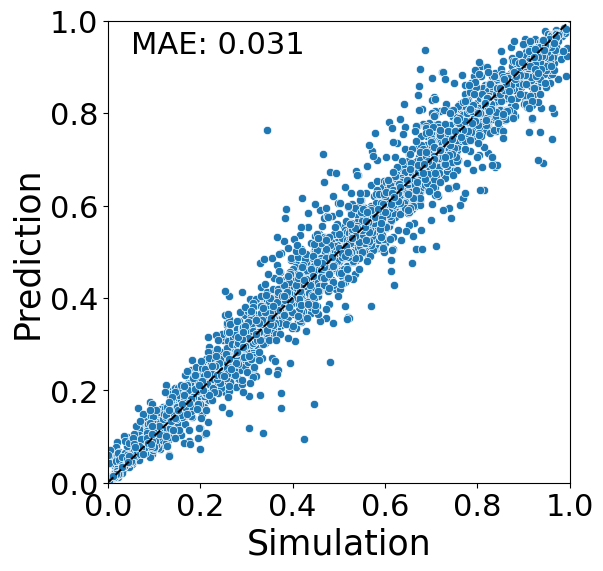

[ 0.37477188  0.74138586 -0.17774099 ...  0.22393992 -0.02253941
 -0.18974438]
[0.08684585 0.06179291 0.05333837 ... 0.91103646 0.91846042 0.90571672]
[0.88643301 0.12292484 0.84406099 ... 0.94828686 0.93087446 0.91656157]
The number of retained samples is:  8872


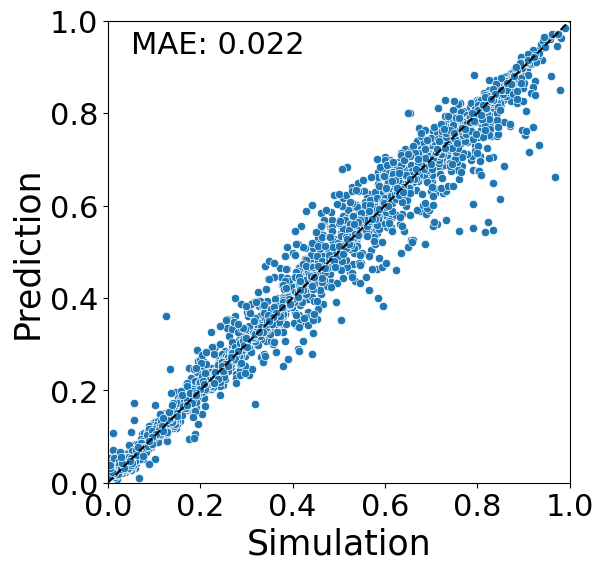

[0.45256223 0.16478313 0.55293468 ... 0.3100811  0.22825925 0.34922318]
[0.0401953  0.51760701 0.10114959 ... 0.45991821 0.74416395 0.36134091]
[0.04110755 0.08340901 0.08747311 ... 0.91670755 0.97163183 0.92054116]
The number of retained samples is:  10000


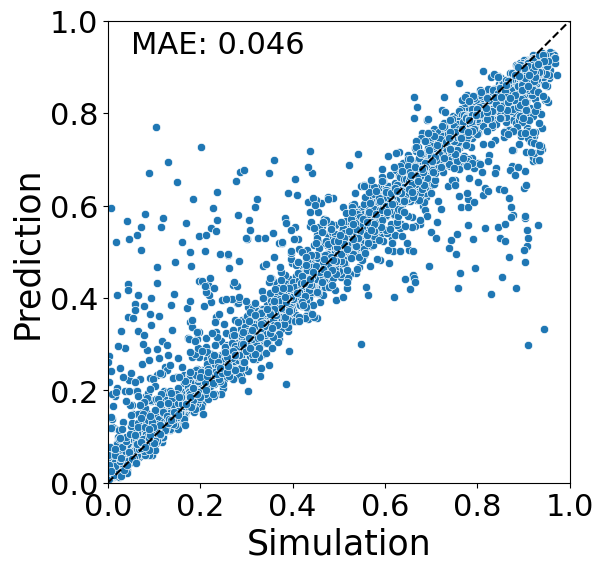

['../Output/DBT005G12_Ecoli_reconstrained/predictors_w_noise/models_100_113C_wnoise_filtered.joblib']

In [ ]:
# only train for the respective modality

models_100_113C = {
    r: eval_RF_sim_pred(
        path_to_fluxes = "../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_fluxes.csv", 
        path_to_mdvs = "../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_100_113C_wnoise_filtered.csv", 
        path_to_output_dir = "../Output/Ecoli_aerobic/predictors_w_noise/", 
        flux_ratios_dict = flux_ratios_dict_100_113C, 
        labeling_strategy = "100_113C",
        ratio = r
    ) 
    for r in flux_ratios_dict_100_113C.keys()
}

joblib.dump(models_100_113C, filename = "../Output/Ecoli_aerobic/predictors_w_noise/models_100_113C.joblib")

[0.00873085 0.02548254 0.03033776 ... 0.90753832 0.96465428 0.92790325]
[0.94392006 0.90254232 0.86075353 ... 0.9002378  0.90574672 0.98034676]
The number of retained samples is:  9951


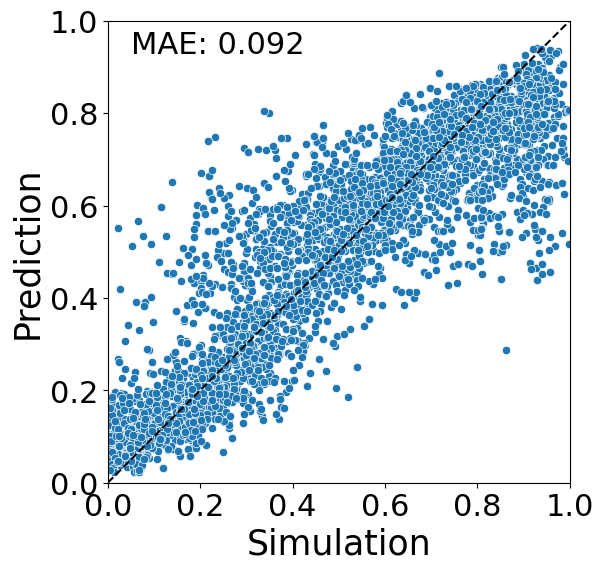

[0.07905135 0.07315701 0.05219488 ... 0.47658988 0.44152625 0.60244176]
[0.02570568 0.02599512 0.01263931 ... 0.93835225 0.91414102 0.95787333]
The number of retained samples is:  6496


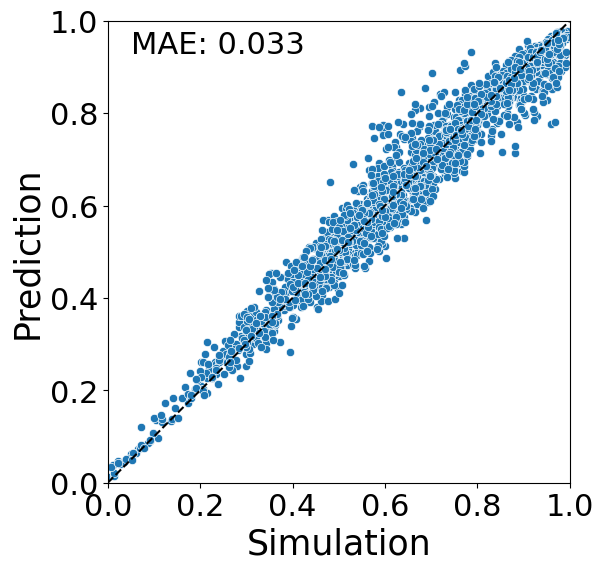

['../Output/DBT005G12_Ecoli_reconstrained/predictors_w_noise/models_20_U13C.joblib']

In [ ]:
flux_ratios_dict_20_U13C = {k: flux_ratios_dict[k] for k in ["pyruvate_from_malic_enzyme", "anaplerosis"]}



models_20_U13C = {
    r: eval_RF_sim_pred(
        path_to_fluxes = "../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_fluxes.csv", 
        path_to_mdvs = "../Output/Ecoli_aerobic/ratio_specific_simulations/" + r + "_mdvs_20_U13C_wnoise_filtered.csv", 
        path_to_output_dir = "../Output/Ecoli_aerobic/predictors_w_noise/", 
        flux_ratios_dict = flux_ratios_dict_20_U13C, 
        labeling_strategy = "20_U13C",
        ratio = r
    ) 
    for r in flux_ratios_dict_20_U13C.keys()
}

joblib.dump(models_20_U13C, filename = "../Output/Ecoli_aerobic/predictors_w_noise/models_20_U13C.joblib")

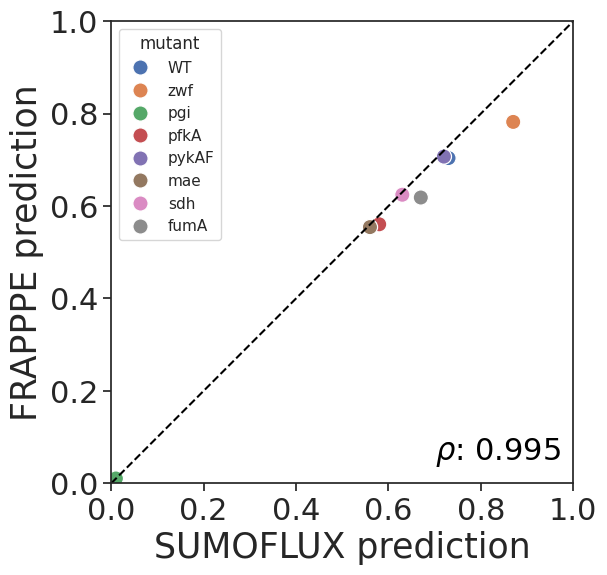

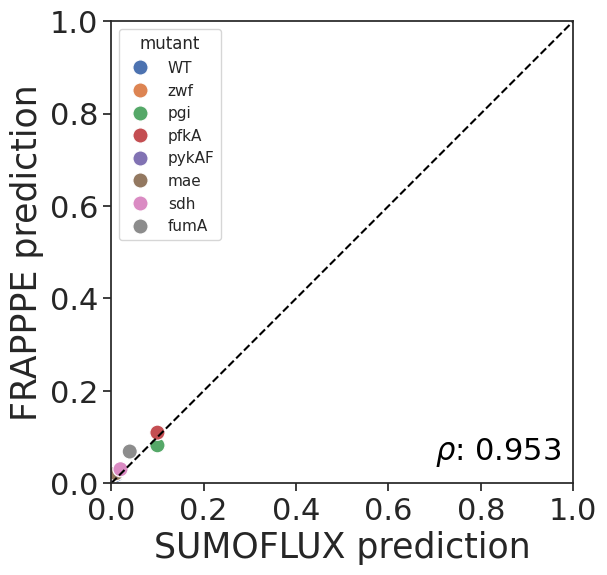

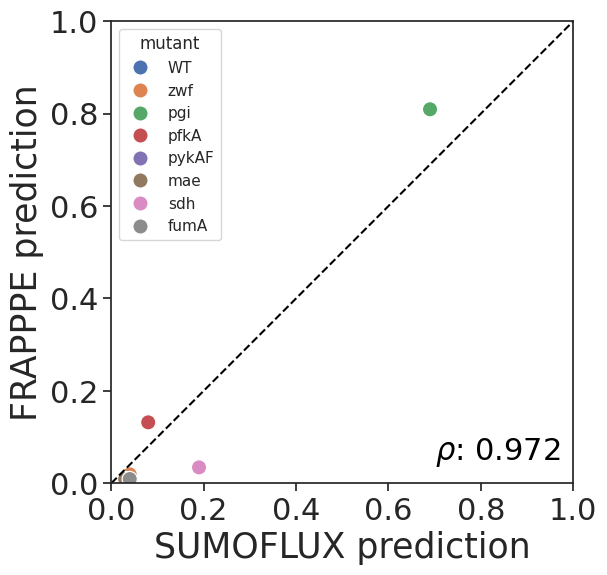

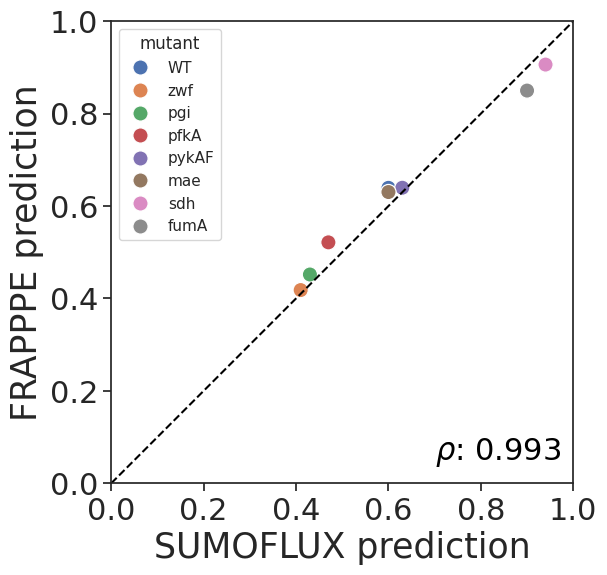

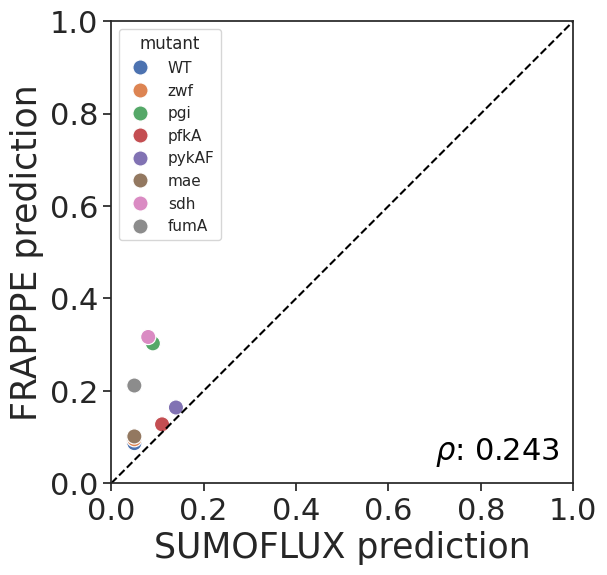

In [ ]:
sns.set_context("notebook", font_scale=1.5)

models_100_113C = joblib.load("../Output/Ecoli_aerobic/predictors_w_noise/models_100_113C.joblib")

models_20_U13C = joblib.load("../Output/Ecoli_aerobic/predictors_w_noise/models_20_U13C.joblib")

output = pd.DataFrame(
    index = flux_ratios_dict.keys(),
    columns = measured_20_U13C.columns
)

for cond in measured_20_U13C.columns:
    for ratio in flux_ratios_dict.keys():
        # Maria estimated glycolysis/PPP, Pyruvate from ED and gluconeogenesis from 100% 1-13C Glucose
        if ratio in ["glycolysis_PPP", "pyruvate_from_ED", "gluconeogenesis"]: 
            # load filtered mdvs
            mdvs = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + ratio + "_mdvs_100_113C_wnoise_filtered.csv", index_col = "Unnamed: 0")
                        
            measured_100_113C_sorted_filtered = measured_100_113C_sorted.loc[mdvs.index]
            
            output.loc[ratio, cond] = models_100_113C[ratio].predict(measured_100_113C_sorted_filtered[[cond]].transpose())[0]
            
        else: 
            
            mdvs = pd.read_csv("../Output/Ecoli_aerobic/ratio_specific_simulations/" + ratio + "_mdvs_20_U13C_wnoise_filtered.csv", index_col = "Unnamed: 0")
                        
            measured_20_U13C_sorted_filtered = measured_20_U13C_sorted.loc[mdvs.index]
            
            output.loc[ratio, cond] = models_20_U13C[ratio].predict(measured_20_U13C_sorted_filtered[[cond]].transpose())[0]

# load data from sumoflux paper

mzk2016 = pd.read_csv("../Data/Ecoli_aerobic/flux_ratios_kogadeeva_2016.csv")

mzk2016_long = mzk2016.melt(
    id_vars = "ratio", 
    var_name = "mutant",
    value_name = "sumoflux_ratio"
).replace(
    to_replace = {"ratio": "/| "},
    value = "_", 
    regex=True
)
output["ratio"] = output.index

output_long = output.melt(
    id_vars = "ratio", 
    var_name = "mutant", 
    value_name = "hopsy_ratio"
)

# for some reason, those dataframes cannot be merged. what type are sumoflux_ratio and hopsy_ratio?

def clean(x):
    x = str(x)
    x = x.strip()
    return x

mzk2016_long["mutant"] = mzk2016_long["mutant"].apply(clean)
output_long["mutant"] = output_long["mutant"].apply(clean)

# apparently there were some trailing whitespaces or something similar, so I needed to clean the names using the clean function

comp = mzk2016_long.merge(output_long, how = "outer", on = ["ratio", "mutant"])

comp["hopsy_ratio"] = np.where(comp["hopsy_ratio"] <= 0, 0, comp["hopsy_ratio"])

# write out table with flux ratio predictions

comp.to_csv("../Output/Ecoli_aerobic/predictors_w_noise/comparison.csv")

# calculate pearson correlation between predictions

comp["hopsy_ratio"] = comp["hopsy_ratio"].astype(float)

sns.set_theme(
    rc={"figure.figsize": (6, 6)},
    style="ticks"  
)

for i in comp.loc[:, "ratio"].unique(): 
    df_sub = comp.query("ratio == @i")
    a = pd.Series(df_sub.loc[:, "sumoflux_ratio"])
    b = pd.Series(df_sub.loc[:, "hopsy_ratio"])
    pearson = a.corr(b).round(3)

    fig, ax = plt.subplots()
    
    sns.scatterplot(
        data = df_sub,
        x = "sumoflux_ratio", 
        y = "hopsy_ratio", 
        hue="mutant",
        s=120
    )

    ax.text(0.7, 0.05, r'$\rho$' + ": " + str(pearson), fontsize=22, color="black")
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.set_aspect('equal', adjustable='box')  
    ax.tick_params(labelsize = 22)
    ax.set_xlabel("SUMOFLUX prediction", fontsize = 25)
    ax.set_ylabel("FRAPPPE prediction", fontsize = 25)
    ax.axline((0, 0), slope=1, color='black', linestyle = "--")
    plt.savefig("../Output/Ecoli_aerobic/predictors_w_noise/sumoflux_vs_hopsy_reconstrained_" +  i + ".pdf", bbox_inches = "tight")



## Calculate labeling patterns of simulations from sumoflux and compare with mdvs directly calculated in SUMOFLUX



Index(['BPG_12_0', 'BPG_12_1', 'BPG_12_2', 'BPG_123_0', 'BPG_123_1',
       'BPG_123_2', 'BPG_123_3', 'BPG_23_0', 'BPG_23_1', 'BPG_23_2',
       'OAA_12_0', 'OAA_12_1', 'OAA_12_2', 'PEP_12_0', 'PEP_12_1', 'PEP_12_2',
       'Pyr_123_0', 'Pyr_123_1', 'Pyr_123_2', 'Pyr_123_3', 'Pyr_23_0',
       'Pyr_23_1', 'Pyr_23_2'],
      dtype='object')
Index(['BPG_12_0', 'BPG_12_1', 'BPG_12_2', 'BPG_123_0', 'BPG_123_1',
       'BPG_123_2', 'BPG_123_3', 'BPG_23_0', 'BPG_23_1', 'BPG_23_2',
       'OAA_12_0', 'OAA_12_1', 'OAA_12_2', 'PEP_12_0', 'PEP_12_1', 'PEP_12_2',
       'Pyr_123_0', 'Pyr_123_1', 'Pyr_123_2', 'Pyr_123_3', 'Pyr_23_0',
       'Pyr_23_1', 'Pyr_23_2'],
      dtype='object')
Index(['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9',
       'Var10',
       ...
       'Var991', 'Var992', 'Var993', 'Var994', 'Var995', 'Var996', 'Var997',
       'Var998', 'Var999', 'Var1000'],
      dtype='object', length=1000)
Index(['s001', 's002', 's003', 's004', 's005', 's006', 's00

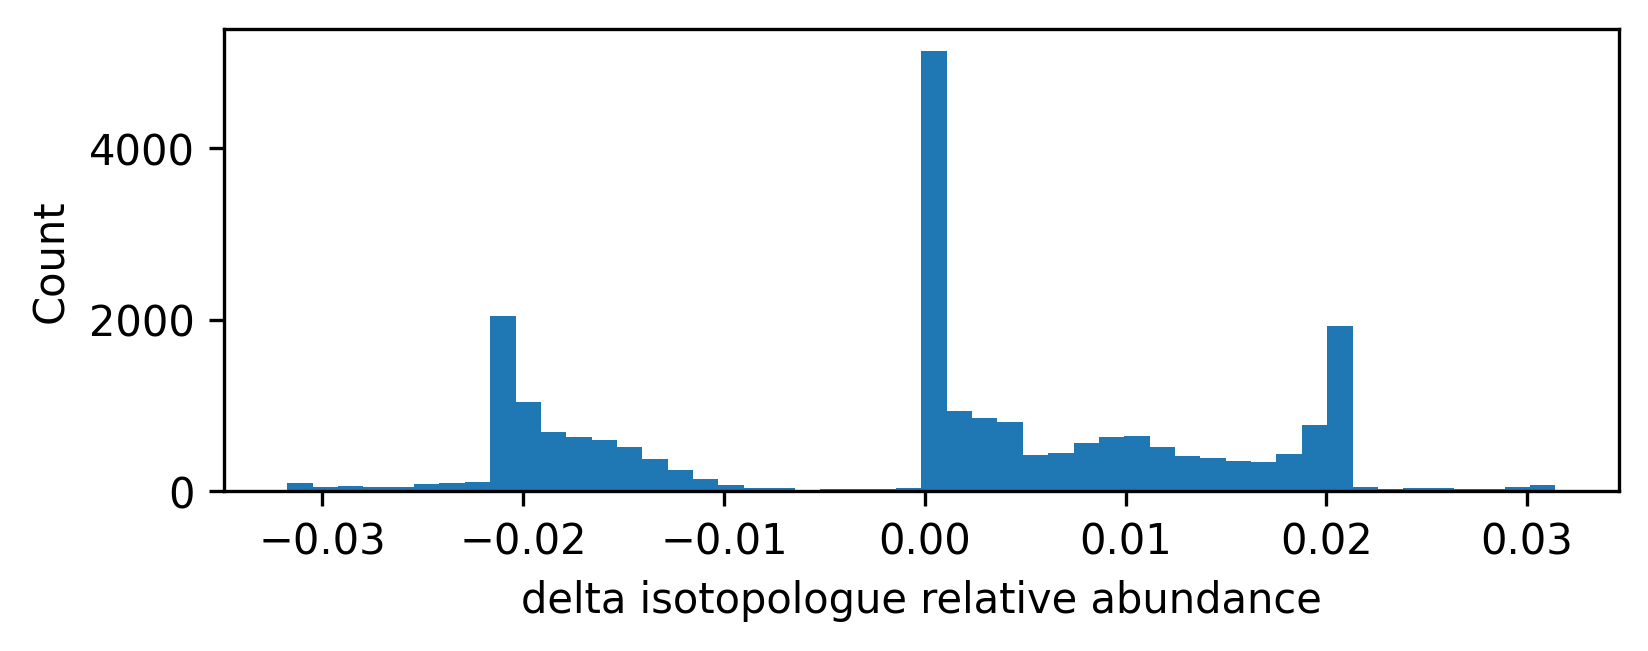

In [ ]:
figure(figsize=(6, 2), dpi=300)

def convert_sumoflux_notation(metabolite):
    met, suf = metabolite.split("_", maxsplit=2)
    min_val = 1
    if suf == met:
        suf = 0

    if met[-2].isdigit():
        min_val, max_val = int(met[-2]), int(met[-1])
        new_labelling = "".join([str(x) for x in range(int(min_val), int(max_val)+1)])
        name = met[:-2]
        if suf != 0:
            suf = int(suf) - min_val + 1
    else:
        new_labelling = met[-1]
        name = met[:-1]
        if suf != 0:
            suf = 1
        
    return f"{name}_{new_labelling}_{suf}"

def get_sumoflux_fluxes(file_prefix):
    df_sumoflux_f = pd.read_csv(f"{file_prefix}_f.csv")
    df_sumoflux_b = pd.read_csv(f"{file_prefix}_b.csv")
    return pd.concat(
        [
            df_sumoflux_f.query("r_irreversible == 1"),
            df_sumoflux_b.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_b"),
            df_sumoflux_f.query("r_irreversible == 0").assign(Row=lambda x: x.Row+"_f")
        ],
        ignore_index=True
    )


def melt_flux_df(data, **kwargs):
    return (
        data
        .reset_index(names="reaction_id")
        .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux")
        .assign(**kwargs)
    )



df_100_1_13c_sumoflux_fluxes = (
    get_sumoflux_fluxes("../Data/Data/Ecoli_aerobic/simulated_ECOLI113C/fluxTable")
    .drop(columns=["r_equation", "r_irreversible"])
    .rename(columns={"Row": "reaction_id"})
    .set_index("reaction_id")
    .iloc[:,0:1000]
)



df_100_1_13c_sumoflux_mdvs = (
    pd.read_csv("../Data/Data/Ecoli_aerobic/simulated_ECOLI113C/mdvTable.csv")
    .assign(Row=lambda x: x.Row.str.replace("PYR", "Pyr").apply(convert_sumoflux_notation))
    .set_index("Row")
    .iloc[:, 0:1000]
)


ecoli_model_file = "../Data/Models/Ecoli/reactions_model_inca_ecoli_corrected.tsv"
ecoli_model = Model("syn_wo_ends")
ecoli_model.read_from_file(ecoli_model_file)

stoic_mat = ecoli_model.get_total_stoichiometric_matrix() 

lb, ub = make_bounds(stoic_mat, 0, 100, specific={"glc_up": [10, 10]})

frapppe_mdvs = get_mdv_results_from_simulations(ecoli_model, df_100_1_13c_sumoflux_fluxes, target_emus_100_113C, Glc_100_113C, parallel=8, as_df=True)

df_100_1_13c_sumoflux_mdvs = df_100_1_13c_sumoflux_mdvs.loc[frapppe_mdvs.index].reindex(frapppe_mdvs.index)

print(df_100_1_13c_sumoflux_mdvs.index)
print(frapppe_mdvs.index)
print(df_100_1_13c_sumoflux_mdvs.columns)
print(frapppe_mdvs.columns)

diffs = (frapppe_mdvs.values - df_100_1_13c_sumoflux_mdvs.values).flatten()

plt.hist(diffs, bins=50)
plt.xlabel("delta isotopologue relative abundance")
plt.ylabel("Count")
plt.savefig("../Output/Ecoli_aerobic/delta_mdv_relab.pdf", bbox_inches = "tight")
plt.show()


In [ ]:
abs(diffs).mean()


0.011383743840710963